<p style="color:#824AE8;font-family:Ubuntu Light;font-size:140%">DATA SCIENCE IN CHEMISTRY</p>

# Getting Started with Openbabel and Pybel

In [1]:
from openbabel import openbabel, pybel

In [2]:
mol = pybel.readstring("smi", "c1ccccc1")

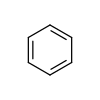

In [3]:
mol

In [4]:
mol.addh()

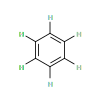

In [5]:
mol

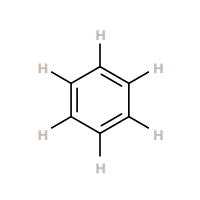

In [6]:
from IPython.display import SVG

img = SVG(mol.write("svg"))
img

In [7]:
mol2 = next(pybel.readfile("sdf", "aspirin.sdf"))

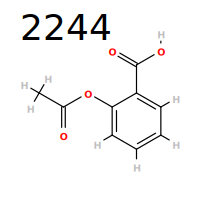

In [8]:
SVG(mol2.write("svg"))

In [9]:
print(mol2.molwt)
print(mol2.formula)
print(mol2.charge)

180.1574199999999
C9H8O4
0


In [10]:
print(mol2.data)

{'MOL Chiral Flag': '0', 'PUBCHEM_COMPOUND_CID': '2244', 'PUBCHEM_COMPOUND_CANONICALIZED': '1', 'PUBCHEM_CACTVS_COMPLEXITY': '212', 'PUBCHEM_CACTVS_HBOND_ACCEPTOR': '4', 'PUBCHEM_CACTVS_HBOND_DONOR': '1', 'PUBCHEM_CACTVS_ROTATABLE_BOND': '3', 'PUBCHEM_CACTVS_SUBSKEYS': 'AAADccBwOAAAAAAAAAAAAAAAAAAAAAAAAAAwAAAAAAAAAAABAAAAGgAACAAADASAmAAyDoAABgCIAiDSCAACCAAkIAAIiAEGCMgMJzaENRqCe2Cl4BEIuYeIyCCOAAAAAAAIAAAAAAAAABAAAAAAAAAAAA==', 'PUBCHEM_IUPAC_OPENEYE_NAME': '2-acetoxybenzoic acid', 'PUBCHEM_IUPAC_CAS_NAME': '2-acetyloxybenzoic acid', 'PUBCHEM_IUPAC_NAME_MARKUP': '2-acetyloxybenzoic acid', 'PUBCHEM_IUPAC_NAME': '2-acetyloxybenzoic acid', 'PUBCHEM_IUPAC_SYSTEMATIC_NAME': '2-acetyloxybenzoic acid', 'PUBCHEM_IUPAC_TRADITIONAL_NAME': '2-acetoxybenzoic acid', 'PUBCHEM_IUPAC_INCHI': 'InChI=1S/C9H8O4/c1-6(10)13-8-5-3-2-4-7(8)9(11)12/h2-5H,1H3,(H,11,12)', 'PUBCHEM_IUPAC_INCHIKEY': 'BSYNRYMUTXBXSQ-UHFFFAOYSA-N', 'PUBCHEM_XLOGP3': '1.2', 'PUBCHEM_EXACT_MASS': '180.04225873', 'PUBCHEM_MOLECULAR_FORM

In [11]:
mol2cif = mol2.write("cif")
mol2cif

"# CIF file generated by openbabel 3.1.0, see https://openbabel.org\ndata_I\n_chemical_name_common '2244'\nloop_\n    _atom_site_label\n    _atom_site_type_symbol\n    _atom_site_fract_x\n    _atom_site_fract_y\n    _atom_site_fract_z\n    _atom_site_occupancy\n    O0       O        3.73200   -0.06000    0.00000    1.000\n    O1       O        6.33010    1.44000    0.00000    1.000\n    O2       O        4.59810    1.44000    0.00000    1.000\n    O3       O        2.86600   -1.56000    0.00000    1.000\n    C4       C        4.59810   -0.56000    0.00000    1.000\n    C5       C        5.46410   -0.06000    0.00000    1.000\n    C6       C        4.59810   -1.56000    0.00000    1.000\n    C7       C        6.33010   -0.56000    0.00000    1.000\n    C8       C        5.46410   -2.06000    0.00000    1.000\n    C9       C        6.33010   -1.56000    0.00000    1.000\n    C10      C        5.46410    0.94000    0.00000    1.000\n    C11      C        2.86600   -0.56000    0.00000    1

In [13]:
mol2.write("cif", "aspirin_cif.cif")

___

## Format Conversion

In [14]:
def convert_file(inputfile, outputfile, input_format, output_format):
    conv = openbabel.OBConversion()
    conv.OpenInAndOutFiles(inputfile, outputfile)
    conv.SetInAndOutFormats(input_format, output_format)
    conv.Convert()
    

In [15]:
convert_file("aspirin.sdf", "aspirin.xyz", "sdf", "xyz")

#### multi_convert

In [ ]:
# Create a new folder for the output files
newfolder = input("Create a New Folder for your Molecules: ")
if not os.path.exists(newfolder):
    os.makedirs(newfolder, exist_ok=True)
    print(f"Folder created: {newfolder}")
else:
    print(f"Folder already exists: {newfolder}")

In [17]:
import os

In [18]:
def multi_file_convert(file_path, input_format, output_format):
    # Create a new folder for the output files
    newfolder = input("Create a New Folder for your Molecules: ")
    if not os.path.exists(newfolder):
        os.makedirs(newfolder, exist_ok=True)
        print(f"Folder created: {newfolder}")
    else:
        print(f"Folder already exists: {newfolder}")
    
    files_list = os.listdir(file_path)
    for file_name in files_list:
        mol_name = os.path.splitext(file_name)[0]
        inputfile = os.path.join(file_path, file_name)
        outputfile = os.path.join(newfolder, mol_name + '.' + output_format)
        
        conv = openbabel.OBConversion()
        conv.SetInAndOutFormats(input_format, output_format)
        mol = openbabel.OBMol()
        if conv.ReadFile(mol, inputfile):
            conv.WriteFile(mol, outputfile)
        
    print("Conversion Done.")
                

In [19]:
multi_file_convert("PubChem Molecules", "sdf", "cif")

Create a New Folder for your Molecules: PubChem Molecules CIF
Folder created: PubChem Molecules CIF
Conversion Done.
